# Exploring GAN Variants for Balancing Imbalanced Datasets
## Wine Fraud Detection using Vanilla GAN and WGAN-GP

**Dataset:** `gusdelact/wine_fraud` from Hugging Face  
**Task:** Train GANs only on the minority class, generate synthetic minority samples, balance the training set, then compare classifier performance on:

1. Original imbalanced data
2. Data balanced with a Vanilla GAN
3. Data balanced with an advanced GAN variant: **Wasserstein GAN with Gradient Penalty (WGAN-GP)**

**How to use this Colab notebook:** run all cells from top to bottom. The final cells automatically save the figures, metrics, generated samples, and a 4-6 page PDF report.

In [ ]:
# ================================================================
# 0. Colab setup
# ================================================================
# Run this cell first. TensorFlow is already installed in Google Colab.
!pip -q install datasets reportlab

In [1]:
# ================================================================
# 1. Imports and reproducibility
# ================================================================
import os
import math
import json
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.keras.utils.set_random_seed(SEED)
except Exception:
    pass

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: True


In [2]:
# ================================================================
# 2. Project configuration
# ================================================================
DATASET_ID = 'gusdelact/wine_fraud'
TARGET_COLUMN = 'auto'       # keep 'auto' unless your dataset card says the target has another name
TEST_SIZE = 0.20

# GAN training settings. Increase GAN_EPOCHS to 800-1500 for a stronger final run if you have time.
LATENT_DIM = 32
GAN_EPOCHS = 500
BATCH_SIZE = 32
CRITIC_STEPS = 3             # WGAN-GP critic updates per generator update
GP_WEIGHT = 10.0

# Classifier settings
CLASSIFIER_EPOCHS = 120
CLASSIFIER_BATCH_SIZE = 32

# Output folders
OUTPUT_DIR = Path('wine_fraud_gan_outputs')
FIG_DIR = OUTPUT_DIR / 'figures'
DATA_DIR = OUTPUT_DIR / 'data'
REPORT_DIR = OUTPUT_DIR / 'report'
for p in [OUTPUT_DIR, FIG_DIR, DATA_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Outputs will be saved in:', OUTPUT_DIR.resolve())

Outputs will be saved in: /content/wine_fraud_gan_outputs


## 1. Dataset Selection and Imbalance Analysis

This section loads the Hugging Face dataset, detects the target column, identifies the minority class, and visualizes the imbalance. For the wine fraud dataset, the minority class is expected to represent the fraudulent/rare class. The code also handles small format differences automatically.

In [3]:
# ================================================================
# 3. Load the Hugging Face dataset
# ================================================================
def load_hf_dataset_to_dataframe(dataset_id: str) -> pd.DataFrame:
    """Load any Hugging Face tabular dataset into one pandas DataFrame."""
    ds = load_dataset(dataset_id)
    if isinstance(ds, DatasetDict):
        frames = []
        for split_name, split_data in ds.items():
            temp = split_data.to_pandas()
            temp['__hf_split__'] = split_name
            frames.append(temp)
        df_loaded = pd.concat(frames, ignore_index=True)
    else:
        df_loaded = ds.to_pandas()
        df_loaded['__hf_split__'] = 'train'
    return df_loaded

try:
    df = load_hf_dataset_to_dataframe(DATASET_ID)
except Exception as e:
    raise RuntimeError(
        "Could not load the Hugging Face dataset. Check that the runtime has internet access "
        f"and that DATASET_ID='{DATASET_ID}' is correct. Original error: {e}"
    )

# Basic cleaning
original_shape = df.shape
df = df.loc[:, ~df.columns.duplicated()].copy()
df = df.drop(columns=['__index_level_0__'], errors='ignore')

print('Original shape:', original_shape)
print('Cleaned shape:', df.shape)
display(df.head())
print('\nColumns:')
print(list(df.columns))

README.md:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

wine_fraud.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/6497 [00:00<?, ? examples/s]

Original shape: (6497, 14)
Cleaned shape: (6497, 14)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,__hf_split__
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red,train
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red,train
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red,train
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red,train
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red,train



Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type', '__hf_split__']


In [4]:
# ================================================================
# 4. Automatically detect the target column and convert labels to binary
# ================================================================
def clean_possible_numeric_columns(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Convert columns to numeric when most non-null values are numeric-looking."""
    out = dataframe.copy()
    missing_markers = ['?', 'NA', 'N/A', 'na', 'null', 'None', '']
    for col in out.columns:
        if out[col].dtype == 'object':
            temp = out[col].replace(missing_markers, np.nan)
            converted = pd.to_numeric(temp, errors='coerce')
            non_missing = temp.notna().sum()
            if non_missing > 0 and converted.notna().sum() / non_missing >= 0.85:
                out[col] = converted
            else:
                out[col] = temp
    return out


def detect_target_column(dataframe: pd.DataFrame, preferred='auto') -> str:
    """Robust target-column detection for common tabular classification datasets."""
    if preferred != 'auto' and preferred in dataframe.columns:
        return preferred

    priority_names = [
        'quality', 'target', 'label', 'labels', 'class', 'classes',
        'fraud', 'is_fraud', 'wine_quality', 'status', 'category', 'y'
    ]
    lower_map = {c.lower().strip(): c for c in dataframe.columns}
    for name in priority_names:
        if name in lower_map:
            return lower_map[name]

    # Prefer a low-cardinality non-ID column.
    candidates = []
    for col in dataframe.columns:
        if col.startswith('__'):
            continue
        nunique = dataframe[col].nunique(dropna=True)
        if 2 <= nunique <= 20:
            candidates.append((col, nunique, dataframe[col].dtype))

    # Put object/category columns first, then lower cardinality columns.
    candidates = sorted(
        candidates,
        key=lambda x: (0 if str(x[2]) in ['object', 'category', 'bool'] else 1, x[1])
    )
    if candidates:
        return candidates[0][0]

    # Last resort: final column.
    return dataframe.columns[-1]

# Remove fully empty rows/columns and convert numeric-looking strings.
df = df.dropna(axis=1, how='all').dropna(axis=0, how='all').reset_index(drop=True)
df = clean_possible_numeric_columns(df)

target_col = detect_target_column(df, TARGET_COLUMN)
print('Detected target column:', target_col)

# Create binary target: minority class = positive class (1), all other classes = 0.
y_raw = df[target_col].astype(str).str.strip()
class_counts_raw = y_raw.value_counts(dropna=False)
minority_label = class_counts_raw.idxmin()
majority_label = class_counts_raw.idxmax()

df_model = df.drop(columns=['__hf_split__'], errors='ignore').copy()
y_binary = (y_raw == minority_label).astype(int)
X_raw = df_model.drop(columns=[target_col]).copy()

print('\nOriginal target distribution:')
display(class_counts_raw.to_frame('count'))
print(f"\nPositive class / minority class: {minority_label!r}")
print(f"Majority class: {majority_label!r}")
print(f"Binary positive rate: {y_binary.mean():.4f}")

if y_binary.nunique() < 2:
    raise ValueError('The detected target column did not produce at least two classes. Set TARGET_COLUMN manually.')
if y_binary.sum() < 5:
    raise ValueError('The minority class has fewer than 5 samples, which is too small for this GAN experiment.')

Detected target column: quality

Original target distribution:


,count
quality,
Legit,6251
Fraud,246



Positive class / minority class: 'Fraud'
Majority class: 'Legit'
Binary positive rate: 0.0379


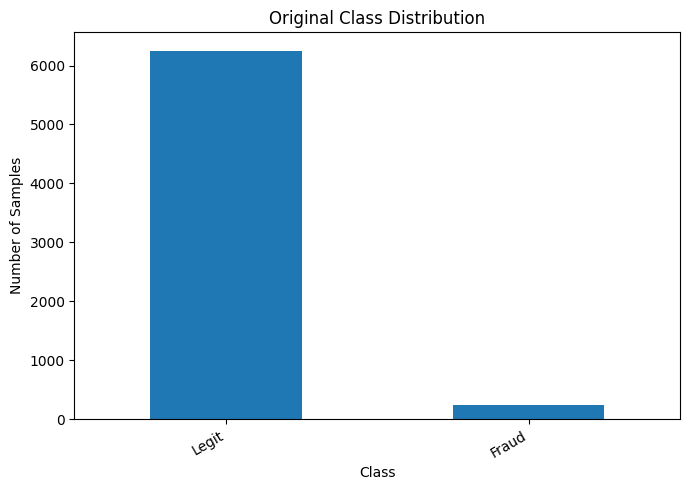

,class,count,percentage
0,Legit,6251,96.21
1,Fraud,246,3.79


Imbalance ratio majority/minority: 25.41:1


In [5]:
# ================================================================
# 5. Visualize and save the class imbalance
# ================================================================
class_counts_binary = pd.Series(y_binary).map({0: f'Non-{minority_label}', 1: str(minority_label)}).value_counts()
imbalance_ratio = class_counts_raw.max() / class_counts_raw.min()

plt.figure(figsize=(7, 5))
class_counts_raw.plot(kind='bar')
plt.title('Original Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
class_plot_path = FIG_DIR / 'class_distribution.png'
plt.savefig(class_plot_path, dpi=180, bbox_inches='tight')
plt.show()

summary_df = pd.DataFrame({
    'class': class_counts_raw.index.astype(str),
    'count': class_counts_raw.values,
    'percentage': (class_counts_raw.values / class_counts_raw.sum() * 100).round(2)
})
display(summary_df)
print(f'Imbalance ratio majority/minority: {imbalance_ratio:.2f}:1')
summary_df.to_csv(DATA_DIR / 'class_distribution_summary.csv', index=False)

## 2. Preprocessing and Train/Test Split

The train/test split is stratified so the test set keeps the original imbalance. The preprocessing pipeline imputes missing values, standardizes numeric columns, and one-hot encodes categorical columns. The GANs and classifier are trained on the processed numerical feature matrix.

In [6]:
# ================================================================
# 6. Train/test split and preprocessing
# ================================================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y_binary,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_binary
)

numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_raw.columns if c not in numeric_cols]

try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

transformers = []
if numeric_cols:
    numeric_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    transformers.append(('numeric', numeric_pipeline, numeric_cols))
if categorical_cols:
    categorical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', onehot)
    ])
    transformers.append(('categorical', categorical_pipeline, categorical_cols))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')
X_train = preprocessor.fit_transform(X_train_raw).astype('float32')
X_test = preprocessor.transform(X_test_raw).astype('float32')
y_train = y_train.to_numpy().astype('int32')
y_test = y_test.to_numpy().astype('int32')

try:
    feature_names = preprocessor.get_feature_names_out().tolist()
except Exception:
    feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Number of processed features:', len(feature_names))
print('Training class counts:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Test class counts:', dict(zip(*np.unique(y_test, return_counts=True))))

Train shape: (5197, 13)
Test shape: (1300, 13)
Number of processed features: 13
Training class counts: {np.int32(0): np.int64(5000), np.int32(1): np.int64(197)}
Test class counts: {np.int32(0): np.int64(1251), np.int32(1): np.int64(49)}


## 3. GAN Implementation

Both GANs are trained only on minority-class training samples.

- **Vanilla GAN:** generator and discriminator trained with binary cross-entropy.
- **WGAN-GP:** generator and critic trained with Wasserstein loss plus gradient penalty, which usually gives more stable training for tabular synthetic data than a basic GAN.

In [7]:
# ================================================================
# 7. GAN helper functions
# ================================================================
def build_generator(latent_dim: int, output_dim: int) -> keras.Model:
    model = keras.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(64),
        layers.LeakyReLU(negative_slope=0.2),
        layers.BatchNormalization(),
        layers.Dense(128),
        layers.LeakyReLU(negative_slope=0.2),
        layers.BatchNormalization(),
        layers.Dense(64),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(output_dim, activation='linear')
    ], name='generator')
    return model


def build_discriminator(input_dim: int) -> keras.Model:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.25),
        layers.Dense(64),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.20),
        layers.Dense(1, activation='sigmoid')
    ], name='discriminator')
    return model


def build_critic(input_dim: int) -> keras.Model:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.20),
        layers.Dense(64),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dense(1, activation='linear')
    ], name='critic')
    return model


def clip_synthetic_to_minority_range(X_synth: np.ndarray, X_minority: np.ndarray) -> np.ndarray:
    """Clip synthetic samples to robust feature ranges seen in real minority training data."""
    lower = np.percentile(X_minority, 1, axis=0)
    upper = np.percentile(X_minority, 99, axis=0)
    return np.clip(X_synth, lower, upper).astype('float32')


def make_tf_dataset(X_array: np.ndarray, batch_size: int):
    return (
        tf.data.Dataset.from_tensor_slices(X_array.astype('float32'))
        .shuffle(buffer_size=max(len(X_array), 1), seed=SEED, reshuffle_each_iteration=True)
        .batch(batch_size, drop_remainder=False)
        .repeat()
    )

In [8]:
# ================================================================
# 8. Train Vanilla GAN
# ================================================================
def train_vanilla_gan(X_minority: np.ndarray, latent_dim=LATENT_DIM, epochs=GAN_EPOCHS, batch_size=BATCH_SIZE):
    output_dim = X_minority.shape[1]
    generator = build_generator(latent_dim, output_dim)
    discriminator = build_discriminator(output_dim)

    bce = keras.losses.BinaryCrossentropy()
    d_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
    g_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

    dataset = make_tf_dataset(X_minority, batch_size)
    iterator = iter(dataset)
    steps_per_epoch = max(1, math.ceil(len(X_minority) / batch_size))
    history = []

    for epoch in range(1, epochs + 1):
        d_losses, g_losses = [], []
        for _ in range(steps_per_epoch):
            real_batch = next(iterator)
            current_batch = tf.shape(real_batch)[0]

            # Train discriminator
            noise = tf.random.normal((current_batch, latent_dim))
            with tf.GradientTape() as d_tape:
                fake_batch = generator(noise, training=True)
                real_pred = discriminator(real_batch, training=True)
                fake_pred = discriminator(fake_batch, training=True)
                real_loss = bce(tf.ones_like(real_pred) * 0.9, real_pred)  # one-sided label smoothing
                fake_loss = bce(tf.zeros_like(fake_pred), fake_pred)
                d_loss = real_loss + fake_loss
            d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
            d_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))

            # Train generator
            noise = tf.random.normal((current_batch, latent_dim))
            with tf.GradientTape() as g_tape:
                fake_batch = generator(noise, training=True)
                fake_pred = discriminator(fake_batch, training=True)
                g_loss = bce(tf.ones_like(fake_pred), fake_pred)
            g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
            g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))

            d_losses.append(float(d_loss.numpy()))
            g_losses.append(float(g_loss.numpy()))

        if epoch == 1 or epoch % 50 == 0 or epoch == epochs:
            row = {'epoch': epoch, 'd_loss': np.mean(d_losses), 'g_loss': np.mean(g_losses)}
            history.append(row)
            print(f"Vanilla GAN epoch {epoch:4d}/{epochs} | D loss: {row['d_loss']:.4f} | G loss: {row['g_loss']:.4f}")

    return generator, pd.DataFrame(history)

In [9]:
# ================================================================
# 9. Train WGAN-GP
# ================================================================
def gradient_penalty(critic: keras.Model, real: tf.Tensor, fake: tf.Tensor) -> tf.Tensor:
    batch_size = tf.shape(real)[0]
    alpha = tf.random.uniform((batch_size, 1), 0.0, 1.0)
    interpolated = real + alpha * (fake - real)
    with tf.GradientTape() as gp_tape:
        gp_tape.watch(interpolated)
        pred = critic(interpolated, training=True)
    grads = gp_tape.gradient(pred, interpolated)
    norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=1) + 1e-8)
    return tf.reduce_mean((norm - 1.0) ** 2)


def train_wgan_gp(
    X_minority: np.ndarray,
    latent_dim=LATENT_DIM,
    epochs=GAN_EPOCHS,
    batch_size=BATCH_SIZE,
    critic_steps=CRITIC_STEPS,
    gp_weight=GP_WEIGHT
):
    output_dim = X_minority.shape[1]
    generator = build_generator(latent_dim, output_dim)
    critic = build_critic(output_dim)

    c_optimizer = keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.0, beta_2=0.9)
    g_optimizer = keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.0, beta_2=0.9)

    dataset = make_tf_dataset(X_minority, batch_size)
    iterator = iter(dataset)
    steps_per_epoch = max(1, math.ceil(len(X_minority) / batch_size))
    history = []

    for epoch in range(1, epochs + 1):
        c_losses, g_losses = [], []
        for _ in range(steps_per_epoch):
            # Train critic multiple times
            for _ in range(critic_steps):
                real_batch = next(iterator)
                current_batch = tf.shape(real_batch)[0]
                noise = tf.random.normal((current_batch, latent_dim))
                with tf.GradientTape() as c_tape:
                    fake_batch = generator(noise, training=True)
                    real_score = critic(real_batch, training=True)
                    fake_score = critic(fake_batch, training=True)
                    gp = gradient_penalty(critic, real_batch, fake_batch)
                    c_loss = tf.reduce_mean(fake_score) - tf.reduce_mean(real_score) + gp_weight * gp
                c_grads = c_tape.gradient(c_loss, critic.trainable_variables)
                c_optimizer.apply_gradients(zip(c_grads, critic.trainable_variables))
                c_losses.append(float(c_loss.numpy()))

            # Train generator
            real_batch = next(iterator)
            current_batch = tf.shape(real_batch)[0]
            noise = tf.random.normal((current_batch, latent_dim))
            with tf.GradientTape() as g_tape:
                fake_batch = generator(noise, training=True)
                fake_score = critic(fake_batch, training=True)
                g_loss = -tf.reduce_mean(fake_score)
            g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
            g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))
            g_losses.append(float(g_loss.numpy()))

        if epoch == 1 or epoch % 50 == 0 or epoch == epochs:
            row = {'epoch': epoch, 'critic_loss': np.mean(c_losses), 'generator_loss': np.mean(g_losses)}
            history.append(row)
            print(f"WGAN-GP epoch {epoch:4d}/{epochs} | Critic loss: {row['critic_loss']:.4f} | G loss: {row['generator_loss']:.4f}")

    return generator, pd.DataFrame(history)

In [10]:
# ================================================================
# 10. Train both GANs on minority-class training samples only
# ================================================================
X_minority_train = X_train[y_train == 1]
X_majority_train = X_train[y_train == 0]

n_minority = len(X_minority_train)
n_majority = len(X_majority_train)
n_to_generate = max(n_majority - n_minority, 0)

print(f'Minority training samples: {n_minority}')
print(f'Majority training samples: {n_majority}')
print(f'Synthetic minority samples needed to balance training data: {n_to_generate}')

if n_to_generate == 0:
    print('The training data is already balanced or minority is not smaller. GANs will still train, but no extra samples are needed.')

vanilla_generator, vanilla_history = train_vanilla_gan(X_minority_train)
wgan_generator, wgan_history = train_wgan_gp(X_minority_train)

vanilla_history.to_csv(DATA_DIR / 'vanilla_gan_training_history.csv', index=False)
wgan_history.to_csv(DATA_DIR / 'wgan_gp_training_history.csv', index=False)

Minority training samples: 197
Majority training samples: 5000
Synthetic minority samples needed to balance training data: 4803
Vanilla GAN epoch    1/500 | D loss: 1.3092 | G loss: 1.0138
Vanilla GAN epoch   50/500 | D loss: 1.4044 | G loss: 0.8189
Vanilla GAN epoch  100/500 | D loss: 1.3512 | G loss: 0.8213
Vanilla GAN epoch  150/500 | D loss: 1.3350 | G loss: 0.8617
Vanilla GAN epoch  200/500 | D loss: 1.3414 | G loss: 0.8360
Vanilla GAN epoch  250/500 | D loss: 1.3399 | G loss: 0.8663
Vanilla GAN epoch  300/500 | D loss: 1.3477 | G loss: 0.8347
Vanilla GAN epoch  350/500 | D loss: 1.3547 | G loss: 0.8612
Vanilla GAN epoch  400/500 | D loss: 1.3640 | G loss: 0.8264
Vanilla GAN epoch  450/500 | D loss: 1.3295 | G loss: 0.8616
Vanilla GAN epoch  500/500 | D loss: 1.3363 | G loss: 0.8392
WGAN-GP epoch    1/500 | Critic loss: 3.8263 | G loss: 0.6188
WGAN-GP epoch   50/500 | Critic loss: -0.0462 | G loss: -1.0708
WGAN-GP epoch  100/500 | Critic loss: 0.4999 | G loss: 0.4290
WGAN-GP epoch

In [11]:
# ================================================================
# 11. Generate synthetic minority samples and create balanced datasets
# ================================================================
def generate_samples(generator: keras.Model, n_samples: int, latent_dim=LATENT_DIM) -> np.ndarray:
    if n_samples <= 0:
        return np.empty((0, X_train.shape[1]), dtype='float32')
    noise = tf.random.normal((n_samples, latent_dim))
    synth = generator(noise, training=False).numpy().astype('float32')
    return clip_synthetic_to_minority_range(synth, X_minority_train)

X_synth_vanilla = generate_samples(vanilla_generator, n_to_generate)
X_synth_wgan = generate_samples(wgan_generator, n_to_generate)

y_synth = np.ones(n_to_generate, dtype='int32')

X_train_vanilla_balanced = np.vstack([X_train, X_synth_vanilla]).astype('float32')
y_train_vanilla_balanced = np.concatenate([y_train, y_synth]).astype('int32')

X_train_wgan_balanced = np.vstack([X_train, X_synth_wgan]).astype('float32')
y_train_wgan_balanced = np.concatenate([y_train, y_synth]).astype('int32')

# Shuffle the balanced training datasets.
def shuffle_xy(X, y):
    rng = np.random.default_rng(SEED)
    idx = rng.permutation(len(y))
    return X[idx], y[idx]

X_train_vanilla_balanced, y_train_vanilla_balanced = shuffle_xy(X_train_vanilla_balanced, y_train_vanilla_balanced)
X_train_wgan_balanced, y_train_wgan_balanced = shuffle_xy(X_train_wgan_balanced, y_train_wgan_balanced)

print('Original training class counts:', dict(zip(*np.unique(y_train, return_counts=True))))
print('Vanilla GAN balanced class counts:', dict(zip(*np.unique(y_train_vanilla_balanced, return_counts=True))))
print('WGAN-GP balanced class counts:', dict(zip(*np.unique(y_train_wgan_balanced, return_counts=True))))

pd.DataFrame(X_synth_vanilla, columns=feature_names).to_csv(DATA_DIR / 'synthetic_minority_vanilla_gan_encoded.csv', index=False)
pd.DataFrame(X_synth_wgan, columns=feature_names).to_csv(DATA_DIR / 'synthetic_minority_wgan_gp_encoded.csv', index=False)

Original training class counts: {np.int32(0): np.int64(5000), np.int32(1): np.int64(197)}
Vanilla GAN balanced class counts: {np.int32(0): np.int64(5000), np.int32(1): np.int64(5000)}
WGAN-GP balanced class counts: {np.int32(0): np.int64(5000), np.int32(1): np.int64(5000)}


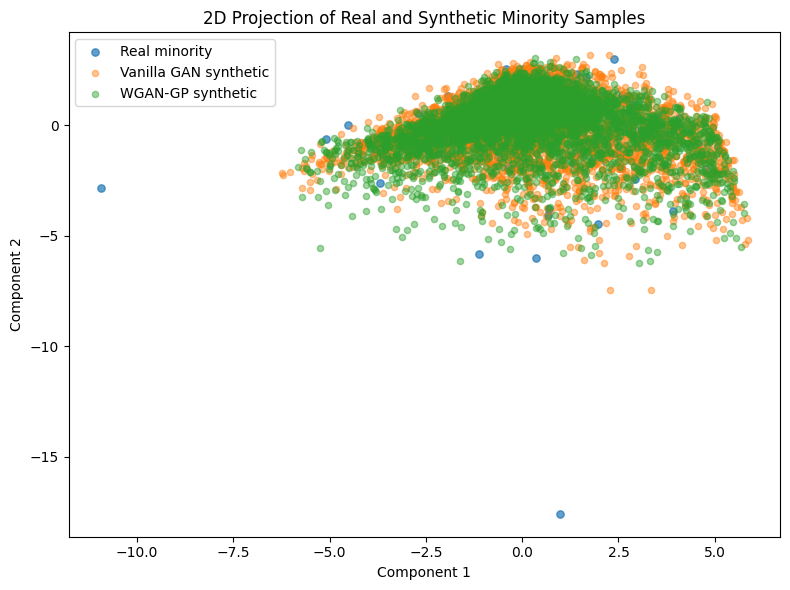

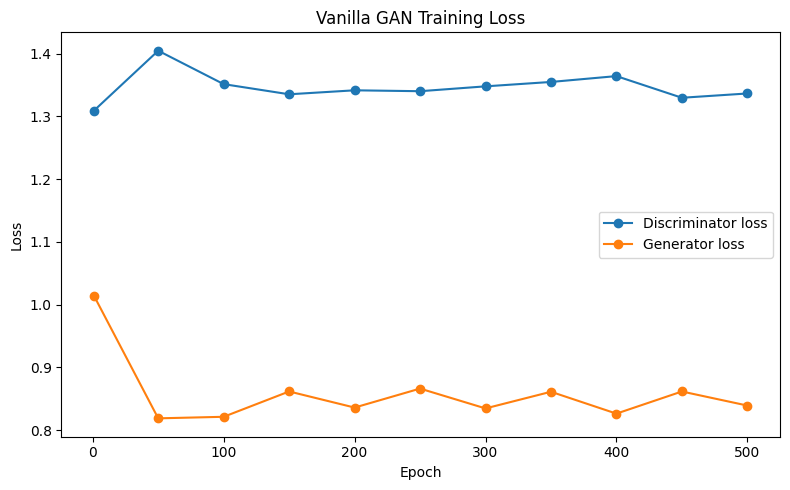

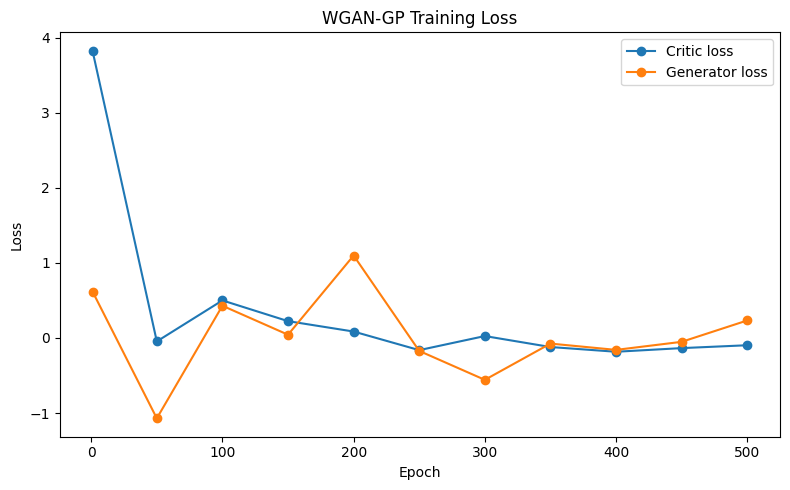

In [12]:
# ================================================================
# 12. Visualize generated samples with PCA-style SVD projection
# ================================================================
def two_dim_projection(reference, *arrays):
    """Project arrays to 2D using SVD fitted on the reference array."""
    mean = reference.mean(axis=0, keepdims=True)
    centered = reference - mean
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    components = vt[:2].T
    projected = [(arr - mean) @ components for arr in arrays]
    return projected

real_proj, vanilla_proj, wgan_proj = two_dim_projection(
    X_minority_train,
    X_minority_train,
    X_synth_vanilla if len(X_synth_vanilla) else X_minority_train[:0],
    X_synth_wgan if len(X_synth_wgan) else X_minority_train[:0]
)

plt.figure(figsize=(8, 6))
plt.scatter(real_proj[:, 0], real_proj[:, 1], alpha=0.7, label='Real minority', s=28)
if len(vanilla_proj):
    plt.scatter(vanilla_proj[:, 0], vanilla_proj[:, 1], alpha=0.45, label='Vanilla GAN synthetic', s=20)
if len(wgan_proj):
    plt.scatter(wgan_proj[:, 0], wgan_proj[:, 1], alpha=0.45, label='WGAN-GP synthetic', s=20)
plt.title('2D Projection of Real and Synthetic Minority Samples')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()
plt.tight_layout()
sample_plot_path = FIG_DIR / 'real_vs_synthetic_projection.png'
plt.savefig(sample_plot_path, dpi=180, bbox_inches='tight')
plt.show()

# Training loss plots
plt.figure(figsize=(8, 5))
plt.plot(vanilla_history['epoch'], vanilla_history['d_loss'], marker='o', label='Discriminator loss')
plt.plot(vanilla_history['epoch'], vanilla_history['g_loss'], marker='o', label='Generator loss')
plt.title('Vanilla GAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
vanilla_loss_path = FIG_DIR / 'vanilla_gan_loss.png'
plt.savefig(vanilla_loss_path, dpi=180, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(wgan_history['epoch'], wgan_history['critic_loss'], marker='o', label='Critic loss')
plt.plot(wgan_history['epoch'], wgan_history['generator_loss'], marker='o', label='Generator loss')
plt.title('WGAN-GP Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
wgan_loss_path = FIG_DIR / 'wgan_gp_loss.png'
plt.savefig(wgan_loss_path, dpi=180, bbox_inches='tight')
plt.show()

## 4. Data Augmentation and Classification

The same MLP classifier architecture is trained three times so that the comparison is fair:

1. Original imbalanced training data
2. Training data balanced with Vanilla GAN synthetic minority samples
3. Training data balanced with WGAN-GP synthetic minority samples

The test set is never augmented, so the metrics reflect performance on real unseen data.

In [13]:
# ================================================================
# 13. MLP classifier and evaluation functions
# ================================================================
def build_classifier(input_dim: int) -> keras.Model:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.15),
        layers.Dense(1, activation='sigmoid')
    ], name='mlp_classifier')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[keras.metrics.BinaryAccuracy(name='accuracy'), keras.metrics.AUC(name='auc')]
    )
    return model


def train_and_evaluate_classifier(name: str, X_tr: np.ndarray, y_tr: np.ndarray):
    model = build_classifier(X_tr.shape[1])
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=12,
            restore_best_weights=True,
            verbose=0
        )
    ]
    history = model.fit(
        X_tr, y_tr,
        validation_split=0.20,
        epochs=CLASSIFIER_EPOCHS,
        batch_size=CLASSIFIER_BATCH_SIZE,
        callbacks=callbacks,
        verbose=0
    )

    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    try:
        auc_value = roc_auc_score(y_test, y_prob)
    except ValueError:
        auc_value = np.nan

    metrics = {
        'scenario': name,
        'train_samples': len(y_tr),
        'train_minority_count': int((y_tr == 1).sum()),
        'train_majority_count': int((y_tr == 0).sum()),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_minority': precision_score(y_test, y_pred, zero_division=0),
        'recall_minority': recall_score(y_test, y_pred, zero_division=0),
        'f1_minority': f1_score(y_test, y_pred, zero_division=0),
        'auc_roc': auc_value
    }
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=[f'Non-{minority_label}', str(minority_label)], zero_division=0, output_dict=True)
    return model, pd.DataFrame(history.history), metrics, cm, report, y_prob, y_pred

In [14]:
# ================================================================
# 14. Train classifiers for all three scenarios
# ================================================================
scenarios = {
    'Original Imbalanced': (X_train, y_train),
    'Balanced with Vanilla GAN': (X_train_vanilla_balanced, y_train_vanilla_balanced),
    'Balanced with WGAN-GP': (X_train_wgan_balanced, y_train_wgan_balanced),
}

classifier_results = {}
all_metrics = []

for scenario_name, (X_tr, y_tr) in scenarios.items():
    print(f'\nTraining classifier: {scenario_name}')
    model, hist, metrics, cm, report, y_prob, y_pred = train_and_evaluate_classifier(scenario_name, X_tr, y_tr)
    classifier_results[scenario_name] = {
        'model': model,
        'history': hist,
        'metrics': metrics,
        'confusion_matrix': cm,
        'classification_report': report,
        'y_prob': y_prob,
        'y_pred': y_pred
    }
    all_metrics.append(metrics)
    hist.to_csv(DATA_DIR / f"classifier_history_{scenario_name.lower().replace(' ', '_').replace('-', '_')}.csv", index=False)
    pd.DataFrame(report).T.to_csv(DATA_DIR / f"classification_report_{scenario_name.lower().replace(' ', '_').replace('-', '_')}.csv")

metrics_df = pd.DataFrame(all_metrics)
metrics_display = metrics_df.copy()
for col in ['accuracy', 'precision_minority', 'recall_minority', 'f1_minority', 'auc_roc']:
    metrics_display[col] = metrics_display[col].round(4)

display(metrics_display)
metrics_df.to_csv(DATA_DIR / 'metrics_summary.csv', index=False)


Training classifier: Original Imbalanced

Training classifier: Balanced with Vanilla GAN

Training classifier: Balanced with WGAN-GP


,scenario,train_samples,train_minority_count,train_majority_count,accuracy,precision_minority,recall_minority,f1_minority,auc_roc
0,Original Imbalanced,5197,197,5000,0.9623,0.5000,0.0408,0.0755,0.8006
1,Balanced with Vanilla GAN,10000,5000,5000,0.9362,0.1852,0.2041,0.1942,0.7219
2,Balanced with WGAN-GP,10000,5000,5000,0.9308,0.1746,0.2245,0.1964,0.7318


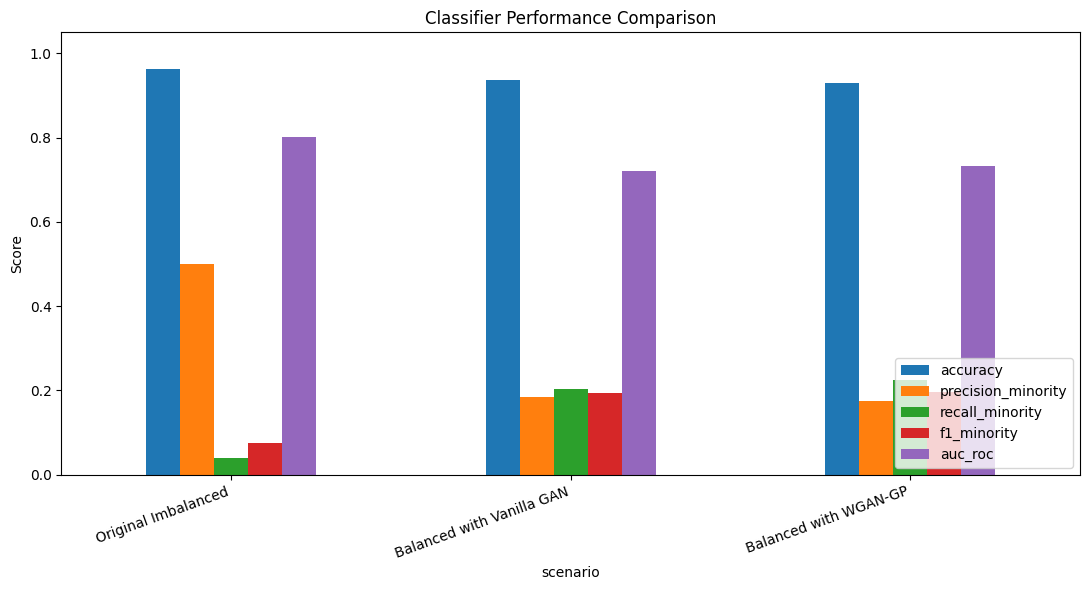

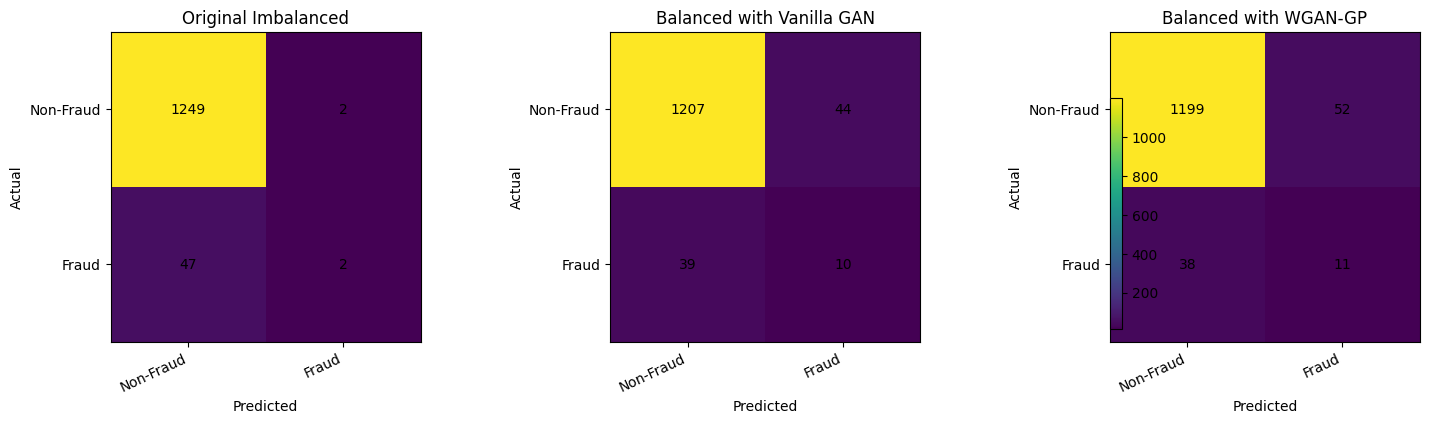

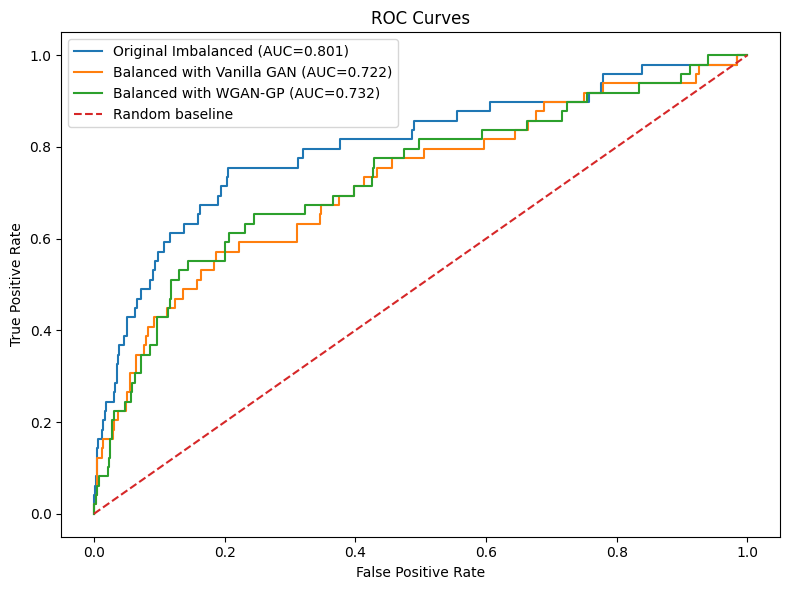

In [15]:
# ================================================================
# 15. Visualize metric comparisons and confusion matrices
# ================================================================
metric_cols = ['accuracy', 'precision_minority', 'recall_minority', 'f1_minority', 'auc_roc']

plot_df = metrics_df.set_index('scenario')[metric_cols]
plt.figure(figsize=(11, 6))
plot_df.plot(kind='bar', ax=plt.gca())
plt.title('Classifier Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
metrics_plot_path = FIG_DIR / 'metrics_comparison.png'
plt.savefig(metrics_plot_path, dpi=180, bbox_inches='tight')
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (scenario_name, result) in zip(axes, classifier_results.items()):
    cm = result['confusion_matrix']
    im = ax.imshow(cm)
    ax.set_title(scenario_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels([f'Non-{minority_label}', str(minority_label)], rotation=25, ha='right')
    ax.set_yticklabels([f'Non-{minority_label}', str(minority_label)])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75)
plt.tight_layout()
cm_plot_path = FIG_DIR / 'confusion_matrices.png'
plt.savefig(cm_plot_path, dpi=180, bbox_inches='tight')
plt.show()

# ROC curves
plt.figure(figsize=(8, 6))
for scenario_name, result in classifier_results.items():
    try:
        fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
        auc_value = roc_auc_score(y_test, result['y_prob'])
        plt.plot(fpr, tpr, label=f'{scenario_name} (AUC={auc_value:.3f})')
    except ValueError:
        pass
plt.plot([0, 1], [0, 1], linestyle='--', label='Random baseline')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
roc_plot_path = FIG_DIR / 'roc_curves.png'
plt.savefig(roc_plot_path, dpi=180, bbox_inches='tight')
plt.show()

## 5. Observations and Conclusion

The cells below automatically identify the strongest model by minority-class F1-score and AUC-ROC. These are especially important here because fraud detection is an imbalanced classification problem; accuracy alone can be misleading when one class dominates the data.

In [16]:
# ================================================================
# 16. Automatic observations based on actual results
# ================================================================
best_f1_row = metrics_df.loc[metrics_df['f1_minority'].idxmax()]
best_auc_row = metrics_df.loc[metrics_df['auc_roc'].idxmax()] if metrics_df['auc_roc'].notna().any() else None

observations = []
observations.append(f"The minority class used as the positive class is: {minority_label!r}.")
observations.append(f"The original class imbalance ratio is approximately {imbalance_ratio:.2f}:1.")
observations.append(f"The best minority-class F1-score was achieved by: {best_f1_row['scenario']} (F1 = {best_f1_row['f1_minority']:.4f}).")
if best_auc_row is not None:
    observations.append(f"The best AUC-ROC was achieved by: {best_auc_row['scenario']} (AUC = {best_auc_row['auc_roc']:.4f}).")
observations.append("The final recommendation should prioritize minority recall and F1-score because missing fraud cases is more harmful than misclassifying a small number of legitimate cases.")

for obs in observations:
    print('-', obs)

with open(REPORT_DIR / 'auto_observations.txt', 'w') as f:
    for obs in observations:
        f.write('- ' + obs + '\n')

- The minority class used as the positive class is: 'Fraud'.
- The original class imbalance ratio is approximately 25.41:1.
- The best minority-class F1-score was achieved by: Balanced with WGAN-GP (F1 = 0.1964).
- The best AUC-ROC was achieved by: Original Imbalanced (AUC = 0.8006).
- The final recommendation should prioritize minority recall and F1-score because missing fraud cases is more harmful than misclassifying a small number of legitimate cases.
